In [20]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [ ]:
# -----------------------------
# 0) Load I/V data
# -----------------------------

def get_vals(T):
    '''
    Run the PyBaMM model and extract the current, voltage, and concentration
    '''
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(RNG=None);
    t = np.linspace(0, sol['Time [s]'].entries[-1], T)
    I = sol.observe(model.variables['Current [A]'])(t)
    V = sol.observe(model.variables['Terminal voltage [V]'])(t)
    cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
    cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.

    # print(param['Nominal cell capacity [A.h]'])
    # print(t[-1])
    return t, V, I, cn, cp

def gen_data_I_c(B, T):
    '''
    B: batch size, T: time steps
    '''
    V = np.zeros((B, T, 1)) # 1 channel
    I = np.zeros((B, T, 1))
    I_dot = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))

    for i in trange(B):
        t, V[i, :, 0], I[i, :, 0], cn[i, :, 0], cp[i, :, 0] = get_vals(T)
        
        I[i, 0, 0] = 0  # Set initial current to zero for consistency

        dt = 1  # Override dt to 1 step for simplicity --> cn_dot = cn_delta

        cn_dot[:, :-1] = np.diff(cn, axis=1)
        cp_dot[:, :-1] = np.diff(cp, axis=1)
        I_dot[:, 1:] = np.diff(I, axis=1) # Backward difference, first time step is zero

        cn_dot[:, -1] = cn_dot[:, -2]  # Pad last time step with second to last value
        cp_dot[:, -1] = cp_dot[:, -2]  # Pad last time

    return I, I_dot, V, cn, cn_dot, cp, cp_dot

In [22]:
sol, model, t_eval, param = exp_pybamm_ver4.generate_data(RNG=None);
cn_max = param['Maximum concentration in negative electrode [mol.m-3]']
cp_max = param['Maximum concentration in positive electrode [mol.m-3]']
print(cn_max, cp_max)

24983.2619938437 51217.9257309275


In [23]:
''' Generate data '''
B = 400
T = int(sol['Time [s]'].entries[-1]) # Use the original time steps from PyBaMM solution

In [24]:
I = np.load('data_c_dot3.npz')['I']
I_dot = np.load('data_c_dot3.npz')['I_dot']
V = np.load('data_c_dot3.npz')['V']
cn = np.load('data_c_dot3.npz')['cn']
cn_dot = np.load('data_c_dot3.npz')['cn_dot']
cp = np.load('data_c_dot3.npz')['cp']
cp_dot = np.load('data_c_dot3.npz')['cp_dot']

In [25]:
''' Split data '''
# Split batches
test_size = 0.1
split = int(test_size * B)

def split_data(data, split):
    return data[:split], data[split:]

# Split and convert to float32 for PyTorch
I_test, I_train = split_data(I, split)
I_dot_test, I_dot_train = split_data(I_dot, split)

cn_test, cn_train = split_data(cn, split)
cn_dot_test, cn_dot_train = split_data(cn_dot, split)

cp_test, cp_train = split_data(cp, split)
cp_dot_test, cp_dot_train = split_data(cp_dot, split)

V_test, V_train = split_data(V, split)

In [81]:
# -----------------------------
# 1) Scaling
# -----------------------------

''' Scale Mark 1 '''
cn_scale = cn_max
cn_dot_scale = np.max(np.abs(cn_dot_train))  # Scale cn_dot by its max absolute value to preserve relative magnitudes

cn_train_s = cn_train / cn_scale
cn_test_s = cn_test / cn_scale
cn_dot_train_s = cn_dot_train / cn_dot_scale    # ≠ cn_dot_train_s = scale(cn_dot_train, MinMaxScaler())
cn_dot_test_s = cn_dot_test / cn_dot_scale

print(f"cn_scale: {cn_scale:.2e}, cn_dot_scale: {cn_dot_scale:.2e}")
print(f"cn_train_s range: [{cn_train_s.min():.2f}, {cn_train_s.max():.2f}]"
      f", cn_dot_train_s range: [{cn_dot_train_s.min():.2f}, {cn_dot_train_s.max():.2f}]")


train_dataset = TensorDataset(torch.tensor(I_train, dtype=torch.float32),    # Not using scaled
                              torch.from_numpy(I_dot_train).float(), 
                              torch.from_numpy(cn_train_s).float(), 
                              torch.from_numpy(cn_dot_train_s).float())

batch_size = int(B/4)
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)


cn_scale: 2.50e+04, cn_dot_scale: 7.66e+01
cn_train_s range: [0.22, 0.80], cn_dot_train_s range: [-1.00, 0.89]


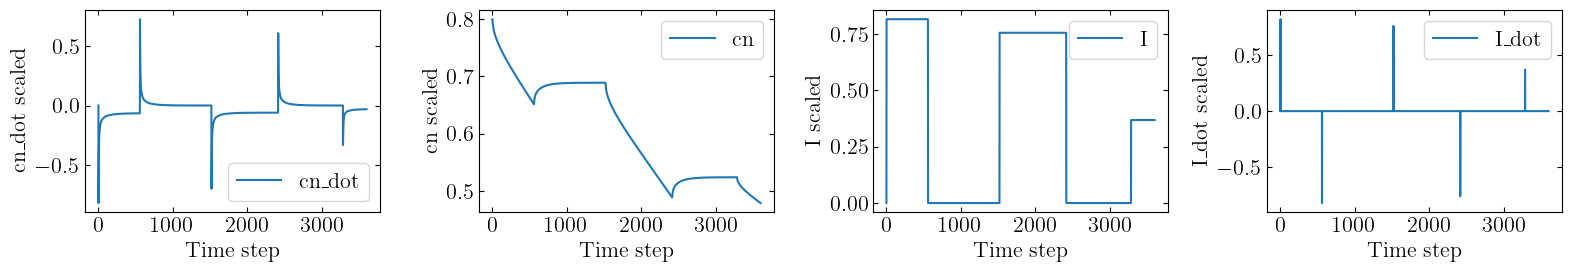

In [82]:
idb = 7

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 3))
ax1.plot(cn_dot_train_s[idb, :, 0], label='cn_dot')
ax1.set_xlabel('Time step')
ax1.set_ylabel('cn_dot scaled')
ax1.legend()
ax2.plot(cn_train_s[idb, :, 0], label='cn')
ax2.set_xlabel('Time step')
ax2.set_ylabel('cn scaled')
ax2.legend()
ax3.plot(I_train[idb, :, 0], label='I')
ax3.set_xlabel('Time step')
ax3.set_ylabel('I scaled')
ax3.legend()
ax4.plot(I_dot_train[idb, :, 0], label='I_dot')
ax4.set_xlabel('Time step')
ax4.set_ylabel('I_dot scaled')
ax4.legend()
plt.tight_layout()

In [83]:
# -----------------------------
# 2) Network
# -----------------------------
    
class Net(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=3, out_features=hidden_dim), # input i_t, i_dot_t, c_t
            nn.Tanh(),
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),  # output c_dot_k
        )

    def forward(self, I, I_dot, c):
        # x: [B*T, 1], c: [B*T, 1]
        x = torch.cat([I, I_dot, c], dim=-1)  # [B*T, 3]
        output = self.net(x)
        return output

In [84]:
# -----------------------------
# 3) Training loop
# -----------------------------

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

''' Mark 1: Unrolled training '''

def training(epochs=50):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        last = None

        for I_batch, I_dot_batch, cn_batch, cn_dot_batch in loader:

            optimizer.zero_grad()

            loss = 0
            dt=1

            K = 40  # Time steps to unroll
            s = torch.randint(0, T-K-1, (1,)).item()    # Random start index for unrolling
            c_pred = cn_batch[:, s, :]

            for k in range(K):

                I_k = I_batch[:, s+k, :]          # shape (B,1)
                I_dot_k = I_dot_batch[:, s+k, :]  # shape (B,1)

                c_dot_hat = model(I_k, I_dot_k, c_pred)

                c_pred = c_pred + dt * c_dot_hat    # Euler forward

                c_true = cn_batch[:, s+k+1, :]  # shape (B,1)

                loss += mse(c_pred, c_true)

            loss.backward()
            optimizer.step()
            last = loss.item()

        history["loss"].append(last)

        print(f'Epoch {ep+1} | loss {last} |')

    return history

In [85]:
history = training(epochs=30)

Epoch 1 | loss 18.78542137145996 |
Epoch 2 | loss 1.8564494848251343 |
Epoch 3 | loss 3.48736572265625 |
Epoch 4 | loss 1.519133448600769 |
Epoch 5 | loss 5.964423656463623 |
Epoch 6 | loss 1.312907099723816 |
Epoch 7 | loss 0.4091794490814209 |
Epoch 8 | loss 0.2231004536151886 |
Epoch 9 | loss 1.5235201120376587 |
Epoch 10 | loss 0.4627287685871124 |
Epoch 11 | loss 0.43673837184906006 |
Epoch 12 | loss 0.2772519886493683 |
Epoch 13 | loss 1.1839970350265503 |
Epoch 14 | loss 0.5251790881156921 |
Epoch 15 | loss 0.320026695728302 |
Epoch 16 | loss 0.43733131885528564 |
Epoch 17 | loss 0.14445342123508453 |
Epoch 18 | loss 0.24623653292655945 |
Epoch 19 | loss 0.16476552188396454 |
Epoch 20 | loss 0.45962393283843994 |
Epoch 21 | loss 0.885460615158081 |
Epoch 22 | loss 0.18912966549396515 |
Epoch 23 | loss 0.24227043986320496 |
Epoch 24 | loss 0.5418207049369812 |
Epoch 25 | loss 0.39003926515579224 |
Epoch 26 | loss 0.42823901772499084 |
Epoch 27 | loss 0.1423661857843399 |
Epoch 28

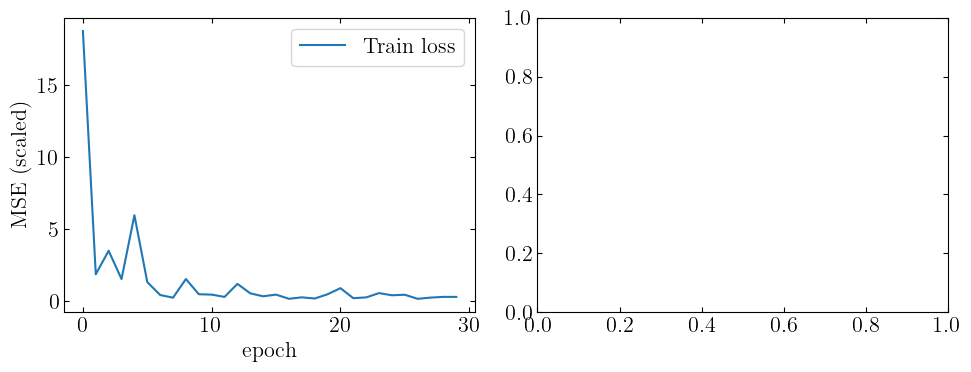

In [86]:
# -----------------------------
# 4) Test + plot
# -----------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE (scaled)")
ax1.legend()

plt.tight_layout()

In [89]:
def step(idx, t, I_t, I_dot, cn_t, cn_euler, dt=1):
    # Predict cn_dot from current I_t and concentration cn_t
    with torch.no_grad():
            cn_dot_hat_s = model(I_t, I_dot, cn_t).item()    # pick item from output tensor

    cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + cn_dot_hat_s * dt * cn_dot_scale / cn_scale  # Euler step: c_{k+1} = c_k + c_dot_k * dt
    return cn_dot_hat_s

0.6356695208863217 0.4376759162866018


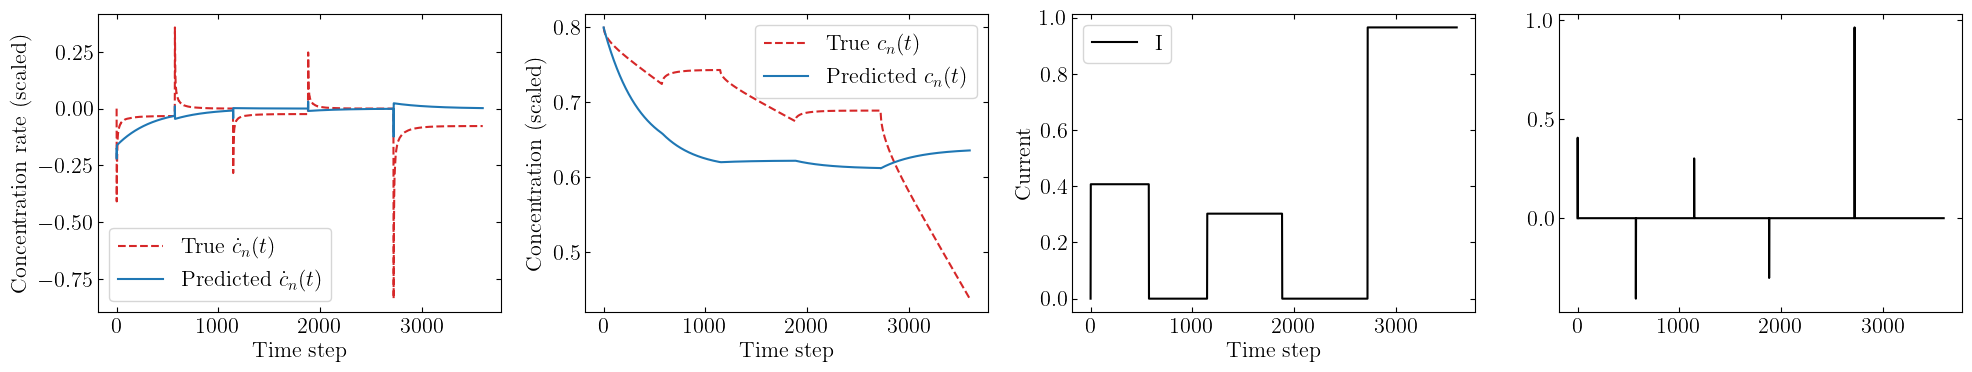

In [90]:
# -----------------------------
# 5) Predict from euler forward 
# -----------------------------
model.eval()
idx = 0

cn_euler = np.zeros_like(cn_test_s)  # (B, T, 1)

''' Using true initial cn, then forward Euler '''
cn_0 = torch.tensor([[cn_test_s[idx, 0, 0]]], dtype=torch.float32).item()
cn_euler[idx, 0, 0] = cn_0


cn_dot_hat_list = []
dt = 1

for t in range(T):
    I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    I_dot_t = torch.tensor([[I_dot_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)

    if t == 0:
        # Predict on initial concentration, then use Euler to step forward
        cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t, cn_euler)
    elif t < T-1:
        cn_t = torch.tensor([[cn_euler[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t, cn_euler)

    cn_dot_hat_list.append(cn_dot_hat)
    # print(f"True cn_dot: {cn_dot_test_s[idx, t, 0]:.4f} | Predicted cn_dot: {cn_dot_hat:.4f}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))

ax1.plot(cn_dot_test_s[idx, :, 0],  color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(I_test[idx, :, 0], label='I', color='black')
ax3.set_xlabel("Time step")
ax3.set_ylabel("Current")
ax3.legend()

ax4.plot(I_dot_test[idx, :, 0], label='I_dot', color='black')
plt.tight_layout()
# plt.savefig('figs/2_JN_PENN_ECM.pdf')

print(cn_euler[idx, -1, 0], cn_test_s[idx, -1, 0])